In [164]:
import os
import numpy as np
import pandas as pd
import unicodedata

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from transformers import AutoTokenizer, AutoModel

In [165]:
SMELLS =  ["God Class", "Feature Envy", "Long Method"]
KEY = ["clean_code", "smell", "username"]
FULL_KEY = KEY + ["dup_id"]

In [166]:
def normalize_colname(c: str) -> str:
    s = unicodedata.normalize("NFKC", str(c))
    s = s.replace("\u200b", "").replace("\ufeff", "")
    return s.strip().lower()

def valid_embedding(v):
    return isinstance(v, (list, tuple, np.ndarray)) and len(v) > 0

def load_prepared_with_dupid(path, smells=SMELLS):
    df = pd.read_pickle(path).copy()

    df = df.rename(columns={c: normalize_colname(c) for c in df.columns})

    missing = set(KEY + ["embedding"]) - set(df.columns)
    if missing:
        raise ValueError(
            f"En {path} faltan columnas: {missing}. Columnas actuales: {df.columns.tolist()}"
        )

    df["smell"] = df["smell"].astype(str).str.strip().str.lower()
    df["username"] = df["username"].astype(str).str.strip().str.lower()
    df["clean_code"] = df["clean_code"].astype(str)

    df = df[df["smell"].isin([s.lower() for s in smells])].copy()

    df = df.dropna(subset=KEY + ["embedding"])
    df = df[df["embedding"].apply(valid_embedding)].copy()

    df["dup_id"] = df.groupby(KEY).cumcount()

    return df[FULL_KEY + ["embedding"]].reset_index(drop=True)

In [167]:
def build_merged_with_dupid(path_openai, path_codebert):
    oa = load_prepared_with_dupid(path_openai)
    cb = load_prepared_with_dupid(path_codebert)

    print("OpenAI filas:", len(oa))
    print("CodeBERT filas:", len(cb))
    print("Duplicados OpenAI por KEY (sin dup_id):", oa.duplicated(subset=KEY).sum())
    print("Duplicados CodeBERT por KEY (sin dup_id):", cb.duplicated(subset=KEY).sum())

    print("Duplicados OpenAI por FULL_KEY:", oa.duplicated(subset=FULL_KEY).sum())
    print("Duplicados CodeBERT por FULL_KEY:", cb.duplicated(subset=FULL_KEY).sum())

    merged = oa.merge(
        cb,
        on=FULL_KEY,
        how="inner",
        suffixes=("_openai", "_codebert"),
        validate="one_to_one"
    )

    print("\nMerged filas (inner, one_to_one con dup_id):", len(merged))
    print("\nDistribución de clases en merged:")
    print(merged["smell"].value_counts())

    return merged

In [168]:
def group_split_indices(merged, test_size=0.2, random_state=42):
    idx = np.arange(len(merged))
    groups = merged["clean_code"].to_numpy()

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(idx, groups=groups))

    train_codes = set(merged.iloc[train_idx]["clean_code"])
    test_codes = set(merged.iloc[test_idx]["clean_code"])

    print("\n=== Split por clean_code (GroupShuffleSplit) ===")
    print("Filas train:", len(train_idx), "Filas test:", len(test_idx))
    print("Códigos únicos train:", len(train_codes), "Códigos únicos test:", len(test_codes))
    print("Overlap clean_code (debe ser 0):", len(train_codes & test_codes))

    print("\nClases train:")
    print(merged.iloc[train_idx]["smell"].value_counts())
    print("\nClases test:")
    print(merged.iloc[test_idx]["smell"].value_counts())

    return train_idx, test_idx

In [169]:
def eval_with_split(merged, emb_col, train_idx, test_idx):
    X = np.vstack(merged[emb_col].apply(lambda v: np.asarray(v, dtype=float)).to_numpy())

    le = LabelEncoder()
    y = le.fit_transform(merged["smell"])

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_proba = model.predict_proba(X_test)

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0,
        output_dict=True
    )

    metrics_per_smell = (
        pd.DataFrame(report_dict)
        .T
        .reset_index()
        .rename(columns={"index": "smell"})
    )

    metrics_per_smell = metrics_per_smell[
        metrics_per_smell["smell"].isin(le.classes_)
    ].copy()

    metrics_per_smell = metrics_per_smell.rename(columns={
        "precision": "precision",
        "recall": "recall",
        "f1-score": "f1",
        "support": "support"
    })

    metrics_per_smell = metrics_per_smell[
        ["smell", "precision", "recall", "f1", "support"]
    ]

    n_classes = len(le.classes_)
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    roc_auc_ovr_macro = None
    roc_auc_ovr_weighted = None
    roc_auc_ovo_macro = None

    try:
        roc_auc_ovr_macro = roc_auc_score(
            y_test_bin, y_proba, multi_class="ovr", average="macro"
        )
    except Exception:
        pass

    try:
        roc_auc_ovr_weighted = roc_auc_score(
            y_test_bin, y_proba, multi_class="ovr", average="weighted"
        )
    except Exception:
        pass

    try:
        roc_auc_ovo_macro = roc_auc_score(
            y_test_bin, y_proba, multi_class="ovo", average="macro"
        )
    except Exception:
        pass

    roc_auc_per_smell = []
    for i, smell_name in enumerate(le.classes_):
        y_true_i = y_test_bin[:, i]
        y_score_i = y_proba[:, i]

        if len(np.unique(y_true_i)) < 2:
            auc_i = np.nan
        else:
            auc_i = roc_auc_score(y_true_i, y_score_i)

        roc_auc_per_smell.append({
            "smell": smell_name,
            "roc_auc_ovr": auc_i
        })

    roc_auc_per_smell = pd.DataFrame(roc_auc_per_smell)

    metrics_per_smell = metrics_per_smell.merge(
        roc_auc_per_smell,
        on="smell",
        how="left"
    )

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_micro": f1_score(y_test, y_pred, average="micro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "report": classification_report(
            y_test, y_pred, target_names=le.classes_, zero_division=0
        ),
        "report_dict": report_dict,
        "metrics_per_smell": metrics_per_smell.sort_values("f1", ascending=False),
        "roc_auc_ovr_macro": roc_auc_ovr_macro,
        "roc_auc_ovr_weighted": roc_auc_ovr_weighted,
        "roc_auc_ovo_macro": roc_auc_ovo_macro,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classes": list(le.classes_),
        "model": model,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

In [170]:
path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

merged = build_merged_with_dupid(path_openai, path_codebert)
train_idx, test_idx = group_split_indices(merged, test_size=0.2, random_state=42)



OpenAI filas: 911
CodeBERT filas: 911
Duplicados OpenAI por KEY (sin dup_id): 7
Duplicados CodeBERT por KEY (sin dup_id): 7
Duplicados OpenAI por FULL_KEY: 0
Duplicados CodeBERT por FULL_KEY: 0

Merged filas (inner, one_to_one con dup_id): 911

Distribución de clases en merged:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64

=== Split por clean_code (GroupShuffleSplit) ===
Filas train: 789 Filas test: 122
Códigos únicos train: 60 Códigos únicos test: 15
Overlap clean_code (debe ser 0): 0

Clases train:
smell
long method     488
god class       165
feature envy    136
Name: count, dtype: int64

Clases test:
smell
long method     66
feature envy    55
god class        1
Name: count, dtype: int64


# Logistic Regression

In [171]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [172]:
def eval_with_stratified_group_kfold(
    merged,
    emb_col,
    n_splits=5,
    random_state=42
):
    X = np.vstack(
        merged[emb_col].apply(lambda v: np.asarray(v, dtype=float)).to_numpy()
    )

    le = LabelEncoder()
    y = le.fit_transform(merged["smell"].to_numpy())
    class_names = list(le.classes_)
    n_classes = len(class_names)

    groups = merged["clean_code"].to_numpy()

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []
    per_smell_rows = []
    cms = []

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=4000,
                class_weight="balanced"
            ))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        all_y_true.append(y_test)
        all_y_pred.append(y_pred)
        all_y_proba.append(y_proba)

        row = {
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
        }

        y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

        try:
            row["roc_auc_ovr_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            row["roc_auc_ovr_macro"] = np.nan

        try:
            row["roc_auc_ovr_weighted"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            row["roc_auc_ovr_weighted"] = np.nan

        try:
            row["roc_auc_ovo_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovo", average="macro"
            )
        except Exception:
            row["roc_auc_ovo_macro"] = np.nan

        fold_rows.append(row)

        report_dict = classification_report(
            y_test,
            y_pred,
            labels=np.arange(n_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        fold_per_smell = (
            pd.DataFrame(report_dict)
            .T
            .reset_index()
            .rename(columns={"index": "smell", "f1-score": "f1"})
        )

        fold_per_smell = fold_per_smell[fold_per_smell["smell"].isin(class_names)].copy()
        fold_per_smell = fold_per_smell[["smell", "precision", "recall", "f1", "support"]]
        fold_per_smell["fold"] = fold

        auc_rows = []
        for i, smell_name in enumerate(class_names):
            y_true_i = y_test_bin[:, i]
            y_score_i = y_proba[:, i]

            if len(np.unique(y_true_i)) < 2:
                auc_i = np.nan
            else:
                auc_i = roc_auc_score(y_true_i, y_score_i)

            auc_rows.append({
                "smell": smell_name,
                "fold": fold,
                "roc_auc_ovr": auc_i
            })

        auc_df = pd.DataFrame(auc_rows)

        fold_per_smell = fold_per_smell.merge(
            auc_df,
            on=["smell", "fold"],
            how="left"
        )

        per_smell_rows.append(fold_per_smell)
        cms.append(confusion_matrix(y_test, y_pred, labels=np.arange(n_classes)))

    folds_df = pd.DataFrame(fold_rows)
    per_smell_df = pd.concat(per_smell_rows, ignore_index=True)

    summary_global = folds_df.drop(columns=["fold"]).mean(numeric_only=True).to_dict()
    summary_global_std = folds_df.drop(columns=["fold"]).std(numeric_only=True).to_dict()

    metrics_per_smell_mean = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "mean",
            "recall": "mean",
            "f1": "mean",
            "support": "mean",
            "roc_auc_ovr": "mean",
        })
        .sort_values("f1", ascending=False)
    )

    metrics_per_smell_std = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "std",
            "recall": "std",
            "f1": "std",
            "support": "std",
            "roc_auc_ovr": "std",
        })
        .sort_values("f1", ascending=False)
    )

    y_true_all = np.concatenate(all_y_true)
    y_pred_all = np.concatenate(all_y_pred)
    y_proba_all = np.vstack(all_y_proba)

    report_all = classification_report(
        y_true_all,
        y_pred_all,
        labels=np.arange(n_classes),
        target_names=class_names,
        zero_division=0
    )

    cm_sum = np.sum(cms, axis=0)

    return {
        "fold_metrics": folds_df,
        "global_mean": summary_global,
        "global_std": summary_global_std,
        "per_smell_fold_metrics": per_smell_df,
        "metrics_per_smell_mean": metrics_per_smell_mean,
        "metrics_per_smell_std": metrics_per_smell_std,
        "report_all_folds": report_all,
        "confusion_matrix_sum": cm_sum,
        "classes": class_names,
    }

In [173]:
path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

merged = build_merged_with_dupid(path_openai, path_codebert)

res_openai = eval_with_stratified_group_kfold(
    merged,
    emb_col="embedding_openai",
    n_splits=5,
    random_state=42
)

res_codebert = eval_with_stratified_group_kfold(
    merged,
    emb_col="embedding_codebert",
    n_splits=5,
    random_state=42
)

OpenAI filas: 911
CodeBERT filas: 911
Duplicados OpenAI por KEY (sin dup_id): 7
Duplicados CodeBERT por KEY (sin dup_id): 7
Duplicados OpenAI por FULL_KEY: 0
Duplicados CodeBERT por FULL_KEY: 0

Merged filas (inner, one_to_one con dup_id): 911

Distribución de clases en merged:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64


In [174]:
print("\n=== OpenAI: promedio ===")
for k, v in res_openai["global_mean"].items():
    std = res_openai["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} ± {std:.4f}")

print("\nReporte agregado (todos los folds):")
print(res_openai["report_all_folds"])

print("\n=== CodeBERT: promedio ===")
for k, v in res_codebert["global_mean"].items():
    std = res_codebert["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} ± {std:.4f}")

print("\nReporte agregado (todos los folds):")
print(res_codebert["report_all_folds"])


=== OpenAI: promedio ===
n_train: 728.8000 ± 19.1885
n_test: 182.2000 ± 19.1885
accuracy: 0.8159 ± 0.1829
balanced_accuracy: 0.7915 ± 0.2192
f1_macro: 0.7622 ± 0.2251
f1_micro: 0.8159 ± 0.1829
f1_weighted: 0.8030 ± 0.1990
precision_macro: 0.8463 ± 0.1261
recall_macro: 0.7915 ± 0.2192
mcc: 0.6079 ± 0.3479
roc_auc_ovr_macro: 0.9337 ± 0.0706
roc_auc_ovr_weighted: 0.9360 ± 0.0666
roc_auc_ovo_macro: 0.9337 ± 0.0706

Reporte agregado (todos los folds):
              precision    recall  f1-score   support

feature envy       0.57      0.69      0.63       191
   god class       1.00      0.92      0.96       166
 long method       0.88      0.85      0.87       554

    accuracy                           0.83       911
   macro avg       0.82      0.82      0.82       911
weighted avg       0.84      0.83      0.83       911


=== CodeBERT: promedio ===
n_train: 728.8000 ± 19.1885
n_test: 182.2000 ± 19.1885
accuracy: 0.9121 ± 0.1317
balanced_accuracy: 0.8929 ± 0.1969
f1_macro: 0.8619 ± 0.17

In [175]:
print("\n=== OpenAI: métricas por smell (media) ===")
print(res_openai["metrics_per_smell_mean"])

print("\n=== CodeBERT: métricas por smell (media) ===")
print(res_codebert["metrics_per_smell_mean"])


=== OpenAI: métricas por smell (media) ===
          smell  precision    recall        f1  support  roc_auc_ovr
2   long method   0.914177  0.865049  0.862489    110.8     0.938152
1     god class   1.000000  0.826667  0.847059     33.2     0.929560
0  feature envy   0.624754  0.682889  0.577035     38.2     0.933271

=== CodeBERT: métricas por smell (media) ===
          smell  precision    recall        f1  support  roc_auc_ovr
2   long method   0.931935  0.969392  0.943940    110.8     0.979935
1     god class   0.933333  0.886667  0.886437     33.2     0.996226
0  feature envy   0.830669  0.822674  0.755199     38.2     0.987901


In [176]:
comparison = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **res_openai["global_mean"]
    },
    {
        "dataset": "CodeBERT",
        **res_codebert["global_mean"]
    }
]).sort_values("f1_macro", ascending=False)

print("\n=== Comparación global (media 5 folds) ===")
print(comparison)


=== Comparación global (media 5 folds) ===
    dataset  n_train  n_test  accuracy  balanced_accuracy  f1_macro  f1_micro  \
1  CodeBERT    728.8   182.2  0.912108           0.892911  0.861859  0.912108   
0    OpenAI    728.8   182.2  0.815939           0.791535  0.762194  0.815939   

   f1_weighted  precision_macro  recall_macro       mcc  roc_auc_ovr_macro  \
1     0.896848         0.898646      0.892911  0.793957           0.988021   
0     0.803028         0.846310      0.791535  0.607945           0.933661   

   roc_auc_ovr_weighted  roc_auc_ovo_macro  
1              0.981253           0.988021  
0              0.935967           0.933661  


In [177]:
per_smell_comparison = (
    res_openai["metrics_per_smell_mean"]
    .merge(
        res_codebert["metrics_per_smell_mean"],
        on="smell",
        suffixes=("_openai", "_codebert")
    )
)

print("\n=== Comparación por smell ===")
print(per_smell_comparison)


=== Comparación por smell ===
          smell  precision_openai  recall_openai  f1_openai  support_openai  \
0   long method          0.914177       0.865049   0.862489           110.8   
1     god class          1.000000       0.826667   0.847059            33.2   
2  feature envy          0.624754       0.682889   0.577035            38.2   

   roc_auc_ovr_openai  precision_codebert  recall_codebert  f1_codebert  \
0            0.938152            0.931935         0.969392     0.943940   
1            0.929560            0.933333         0.886667     0.886437   
2            0.933271            0.830669         0.822674     0.755199   

   support_codebert  roc_auc_ovr_codebert  
0             110.8              0.979935  
1              33.2              0.996226  
2              38.2              0.987901  


In [178]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix_per_model(results_dict, normalize=False, figsize=(7, 6)):
    for model_name, res in results_dict.items():
        cm = np.array(res["confusion_matrix_sum"])
        classes = res["classes"]

        if normalize:
            cm = cm.astype(float)
            row_sums = cm.sum(axis=1, keepdims=True)
            cm = np.divide(cm, row_sums, where=row_sums != 0)
            values_format = ".2f"
        else:
            values_format = "d"

        fig, ax = plt.subplots(figsize=figsize)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=ax, cmap="Blues", values_format=values_format, colorbar=False)

        ax.set_title(f"Matriz de confusión - {model_name}" + (" (normalizada)" if normalize else ""))
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

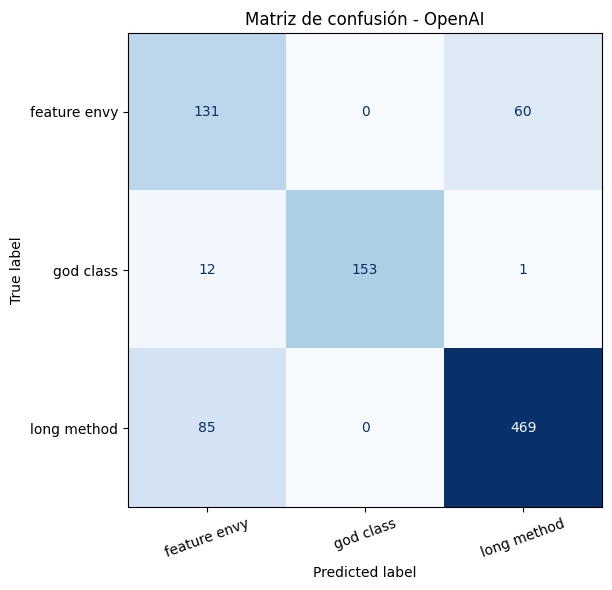

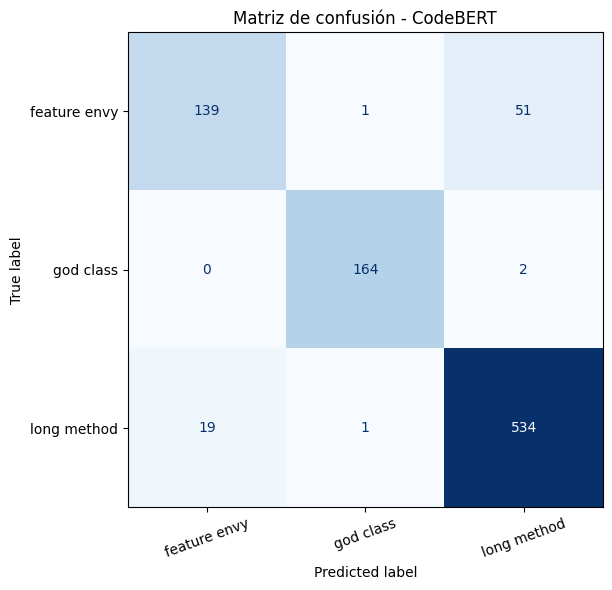

In [179]:
results_models = {
    "OpenAI": res_openai,
    "CodeBERT": res_codebert
}

plot_confusion_matrix_per_model(results_models, normalize=False)
# plot_confusion_matrix_per_model(results_models, normalize=True)

# DecisionTree

In [180]:
from sklearn.tree import DecisionTreeClassifier

def eval_with_stratified_group_kfold_decision_tree(
    merged,
    emb_col,
    n_splits=5,
    random_state=42
):
    X = np.vstack(
        merged[emb_col].apply(lambda v: np.asarray(v, dtype=float)).to_numpy()
    )

    le = LabelEncoder()
    y = le.fit_transform(merged["smell"].to_numpy())
    class_names = list(le.classes_)
    n_classes = len(class_names)

    groups = merged["clean_code"].to_numpy()

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []
    per_smell_rows = []
    cms = []

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", DecisionTreeClassifier(
                random_state=random_state,
                class_weight="balanced"
            ))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        all_y_true.append(y_test)
        all_y_pred.append(y_pred)
        all_y_proba.append(y_proba)

        row = {
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
        }

        y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

        try:
            row["roc_auc_ovr_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            row["roc_auc_ovr_macro"] = np.nan

        try:
            row["roc_auc_ovr_weighted"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            row["roc_auc_ovr_weighted"] = np.nan

        try:
            row["roc_auc_ovo_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovo", average="macro"
            )
        except Exception:
            row["roc_auc_ovo_macro"] = np.nan

        fold_rows.append(row)

        report_dict = classification_report(
            y_test,
            y_pred,
            labels=np.arange(n_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        fold_per_smell = (
            pd.DataFrame(report_dict)
            .T
            .reset_index()
            .rename(columns={"index": "smell", "f1-score": "f1"})
        )

        fold_per_smell = fold_per_smell[fold_per_smell["smell"].isin(class_names)].copy()
        fold_per_smell = fold_per_smell[["smell", "precision", "recall", "f1", "support"]]
        fold_per_smell["fold"] = fold

        auc_rows = []
        for i, smell_name in enumerate(class_names):
            y_true_i = y_test_bin[:, i]
            y_score_i = y_proba[:, i]

            if len(np.unique(y_true_i)) < 2:
                auc_i = np.nan
            else:
                auc_i = roc_auc_score(y_true_i, y_score_i)

            auc_rows.append({
                "smell": smell_name,
                "fold": fold,
                "roc_auc_ovr": auc_i
            })

        auc_df = pd.DataFrame(auc_rows)

        fold_per_smell = fold_per_smell.merge(
            auc_df,
            on=["smell", "fold"],
            how="left"
        )

        per_smell_rows.append(fold_per_smell)
        cms.append(confusion_matrix(y_test, y_pred, labels=np.arange(n_classes)))

    folds_df = pd.DataFrame(fold_rows)
    per_smell_df = pd.concat(per_smell_rows, ignore_index=True)

    summary_global = folds_df.drop(columns=["fold"]).mean(numeric_only=True).to_dict()
    summary_global_std = folds_df.drop(columns=["fold"]).std(numeric_only=True).to_dict()

    metrics_per_smell_mean = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "mean",
            "recall": "mean",
            "f1": "mean",
            "support": "mean",
            "roc_auc_ovr": "mean",
        })
        .sort_values("f1", ascending=False)
    )

    metrics_per_smell_std = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "std",
            "recall": "std",
            "f1": "std",
            "support": "std",
            "roc_auc_ovr": "std",
        })
        .sort_values("f1", ascending=False)
    )

    y_true_all = np.concatenate(all_y_true)
    y_pred_all = np.concatenate(all_y_pred)
    y_proba_all = np.vstack(all_y_proba)

    report_all = classification_report(
        y_true_all,
        y_pred_all,
        labels=np.arange(n_classes),
        target_names=class_names,
        zero_division=0
    )

    cm_sum = np.sum(cms, axis=0)

    return {
        "fold_metrics": folds_df,
        "global_mean": summary_global,
        "global_std": summary_global_std,
        "per_smell_fold_metrics": per_smell_df,
        "metrics_per_smell_mean": metrics_per_smell_mean,
        "metrics_per_smell_std": metrics_per_smell_std,
        "report_all_folds": report_all,
        "confusion_matrix_sum": cm_sum,
        "classes": class_names,
    }


In [182]:
path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

merged = build_merged_with_dupid(path_openai, path_codebert)

print("\n--- Decision Tree Results ---")

res_dt_openai = eval_with_stratified_group_kfold_decision_tree(
    merged,
    emb_col="embedding_openai",
    n_splits=5,
    random_state=42
)

res_dt_codebert = eval_with_stratified_group_kfold_decision_tree(
    merged,
    emb_col="embedding_codebert",
    n_splits=5,
    random_state=42
)

print("\n=== OpenAI Decision Tree: promedio global ===")
for k, v in res_dt_openai["global_mean"].items():
    std = res_dt_openai["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} \u00B1 {std:.4f}")

print("\nReporte agregado (todos los folds) - OpenAI Decision Tree:")
print(res_dt_openai["report_all_folds"])

print("\n=== CodeBERT Decision Tree: promedio global ===")
for k, v in res_dt_codebert["global_mean"].items():
    std = res_dt_codebert["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} \u00B1 {std:.4f}")

print("\nReporte agregado (todos los folds) - CodeBERT Decision Tree:")
print(res_dt_codebert["report_all_folds"])

print("\n=== OpenAI Decision Tree: métricas por smell (media) ===")
print(res_dt_openai["metrics_per_smell_mean"])

print("\n=== CodeBERT Decision Tree: métricas por smell (media) ===")
print(res_dt_codebert["metrics_per_smell_mean"])

comparison_dt = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **res_dt_openai["global_mean"]
    },
    {
        "dataset": "CodeBERT",
        **res_dt_codebert["global_mean"]
    }
]).sort_values("f1_macro", ascending=False)

print("\n=== Comparación global (media 5 folds) - Decision Tree ===")
print(comparison_dt)

per_smell_comparison_dt = (
    res_dt_openai["metrics_per_smell_mean"]
    .merge(
        res_dt_codebert["metrics_per_smell_mean"],
        on="smell",
        suffixes=("_openai", "_codebert")
    )
)

print("\n=== Comparación por smell (media 5 folds) - Decision Tree ===")
print(per_smell_comparison_dt)

OpenAI filas: 911
CodeBERT filas: 911
Duplicados OpenAI por KEY (sin dup_id): 7
Duplicados CodeBERT por KEY (sin dup_id): 7
Duplicados OpenAI por FULL_KEY: 0
Duplicados CodeBERT por FULL_KEY: 0

Merged filas (inner, one_to_one con dup_id): 911

Distribución de clases en merged:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64

--- Decision Tree Results ---

=== OpenAI Decision Tree: promedio global ===
n_train: 728.8000 ± 19.1885
n_test: 182.2000 ± 19.1885
accuracy: 0.5961 ± 0.2395
balanced_accuracy: 0.6109 ± 0.1777
f1_macro: 0.5508 ± 0.2352
f1_micro: 0.5961 ± 0.2395
f1_weighted: 0.5750 ± 0.2524
precision_macro: 0.6398 ± 0.2050
recall_macro: 0.6109 ± 0.1777
mcc: 0.3056 ± 0.3772
roc_auc_ovr_macro: 0.6919 ± 0.1575
roc_auc_ovr_weighted: 0.6340 ± 0.2301
roc_auc_ovo_macro: 0.6919 ± 0.1575

Reporte agregado (todos los folds) - OpenAI Decision Tree:
              precision    recall  f1-score   support

feature envy       0.31      0.42      0.36    

# Naive Bayes

In [183]:
from sklearn.naive_bayes import GaussianNB

def eval_with_stratified_group_kfold_naive_bayes(
    merged,
    emb_col,
    n_splits=5,
    random_state=42
):
    X = np.vstack(
        merged[emb_col].apply(lambda v: np.asarray(v, dtype=float)).to_numpy()
    )

    le = LabelEncoder()
    y = le.fit_transform(merged["smell"].to_numpy())
    class_names = list(le.classes_)
    n_classes = len(class_names)

    groups = merged["clean_code"].to_numpy()

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []
    per_smell_rows = []
    cms = []

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianNB())
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        all_y_true.append(y_test)
        all_y_pred.append(y_pred)
        all_y_proba.append(y_proba)

        row = {
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
        }

        y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

        try:
            row["roc_auc_ovr_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            row["roc_auc_ovr_macro"] = np.nan

        try:
            row["roc_auc_ovr_weighted"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            row["roc_auc_ovr_weighted"] = np.nan

        try:
            row["roc_auc_ovo_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovo", average="macro"
            )
        except Exception:
            row["roc_auc_ovo_macro"] = np.nan

        fold_rows.append(row)

        report_dict = classification_report(
            y_test,
            y_pred,
            labels=np.arange(n_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        fold_per_smell = (
            pd.DataFrame(report_dict)
            .T
            .reset_index()
            .rename(columns={"index": "smell", "f1-score": "f1"})
        )

        fold_per_smell = fold_per_smell[fold_per_smell["smell"].isin(class_names)].copy()
        fold_per_smell = fold_per_smell[["smell", "precision", "recall", "f1", "support"]]
        fold_per_smell["fold"] = fold

        auc_rows = []
        for i, smell_name in enumerate(class_names):
            y_true_i = y_test_bin[:, i]
            y_score_i = y_proba[:, i]

            if len(np.unique(y_true_i)) < 2:
                auc_i = np.nan
            else:
                auc_i = roc_auc_score(y_true_i, y_score_i)

            auc_rows.append({
                "smell": smell_name,
                "fold": fold,
                "roc_auc_ovr": auc_i
            })

        auc_df = pd.DataFrame(auc_rows)

        fold_per_smell = fold_per_smell.merge(
            auc_df,
            on=["smell", "fold"],
            how="left"
        )

        per_smell_rows.append(fold_per_smell)
        cms.append(confusion_matrix(y_test, y_pred, labels=np.arange(n_classes)))

    folds_df = pd.DataFrame(fold_rows)
    per_smell_df = pd.concat(per_smell_rows, ignore_index=True)

    summary_global = folds_df.drop(columns=["fold"]).mean(numeric_only=True).to_dict()
    summary_global_std = folds_df.drop(columns=["fold"]).std(numeric_only=True).to_dict()

    metrics_per_smell_mean = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "mean",
            "recall": "mean",
            "f1": "mean",
            "support": "mean",
            "roc_auc_ovr": "mean",
        })
        .sort_values("f1", ascending=False)
    )

    metrics_per_smell_std = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "std",
            "recall": "std",
            "f1": "std",
            "support": "std",
            "roc_auc_ovr": "std",
        })
        .sort_values("f1", ascending=False)
    )

    y_true_all = np.concatenate(all_y_true)
    y_pred_all = np.concatenate(all_y_pred)
    y_proba_all = np.vstack(all_y_proba)

    report_all = classification_report(
        y_true_all,
        y_pred_all,
        labels=np.arange(n_classes),
        target_names=class_names,
        zero_division=0
    )

    cm_sum = np.sum(cms, axis=0)

    return {
        "fold_metrics": folds_df,
        "global_mean": summary_global,
        "global_std": summary_global_std,
        "per_smell_fold_metrics": per_smell_df,
        "metrics_per_smell_mean": metrics_per_smell_mean,
        "metrics_per_smell_std": metrics_per_smell_std,
        "report_all_folds": report_all,
        "confusion_matrix_sum": cm_sum,
        "classes": class_names,
    }

In [185]:
path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

merged = build_merged_with_dupid(path_openai, path_codebert)

print("\n--- Naive Bayes Results ---")

res_nb_openai = eval_with_stratified_group_kfold_naive_bayes(
    merged,
    emb_col="embedding_openai",
    n_splits=5,
    random_state=42
)

res_nb_codebert = eval_with_stratified_group_kfold_naive_bayes(
    merged,
    emb_col="embedding_codebert",
    n_splits=5,
    random_state=42
)

print("\n=== OpenAI Naive Bayes: promedio global ===")
for k, v in res_nb_openai["global_mean"].items():
    std = res_nb_openai["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} \u00B1 {std:.4f}")

print("\nReporte agregado (todos los folds) - OpenAI Naive Bayes:")
print(res_nb_openai["report_all_folds"])

print("\n=== CodeBERT Naive Bayes: promedio global ===")
for k, v in res_nb_codebert["global_mean"].items():
    std = res_nb_codebert["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} \u00B1 {std:.4f}")

print("\nReporte agregado (todos los folds) - CodeBERT Naive Bayes:")
print(res_nb_codebert["report_all_folds"])

print("\n=== OpenAI Naive Bayes: métricas por smell (media) ===")
print(res_nb_openai["metrics_per_smell_mean"])

print("\n=== CodeBERT Naive Bayes: métricas por smell (media) ===")
print(res_nb_codebert["metrics_per_smell_mean"])

comparison_nb = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **res_nb_openai["global_mean"]
    },
    {
        "dataset": "CodeBERT",
        **res_nb_codebert["global_mean"]
    }
]).sort_values("f1_macro", ascending=False)

print("\n=== Comparación global (media 5 folds) - Naive Bayes ===")
print(comparison_nb)

per_smell_comparison_nb = (
    res_nb_openai["metrics_per_smell_mean"]
    .merge(
        res_nb_codebert["metrics_per_smell_mean"],
        on="smell",
        suffixes=("_openai", "_codebert")
    )
)

print("\n=== Comparación por smell (media 5 folds) - Naive Bayes ===")
print(per_smell_comparison_nb)

OpenAI filas: 911
CodeBERT filas: 911
Duplicados OpenAI por KEY (sin dup_id): 7
Duplicados CodeBERT por KEY (sin dup_id): 7
Duplicados OpenAI por FULL_KEY: 0
Duplicados CodeBERT por FULL_KEY: 0

Merged filas (inner, one_to_one con dup_id): 911

Distribución de clases en merged:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64

--- Naive Bayes Results ---

=== OpenAI Naive Bayes: promedio global ===
n_train: 728.8000 ± 19.1885
n_test: 182.2000 ± 19.1885
accuracy: 0.7060 ± 0.1246
balanced_accuracy: 0.4904 ± 0.1258
f1_macro: 0.4431 ± 0.1098
f1_micro: 0.7060 ± 0.1246
f1_weighted: 0.6186 ± 0.1760
precision_macro: 0.4712 ± 0.1563
recall_macro: 0.4904 ± 0.1258
mcc: 0.3416 ± 0.2317
roc_auc_ovr_macro: 0.6617 ± 0.0897
roc_auc_ovr_weighted: 0.6430 ± 0.1391
roc_auc_ovo_macro: 0.6617 ± 0.0897

Reporte agregado (todos los folds) - OpenAI Naive Bayes:
              precision    recall  f1-score   support

feature envy       0.81      0.57      0.67       191

# Overall Comparison

In [186]:
overall_comparison = pd.concat([comparison, comparison_dt, comparison_nb])

overall_comparison = overall_comparison.rename(columns={'dataset': 'Model_Embedding'})

overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('OpenAI') & overall_comparison['f1_macro'].isin(comparison['f1_macro']), 'Model'] = 'Logistic Regression'
overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('CodeBERT') & overall_comparison['f1_macro'].isin(comparison['f1_macro']), 'Model'] = 'Logistic Regression'

overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('OpenAI') & overall_comparison['f1_macro'].isin(comparison_dt['f1_macro']), 'Model'] = 'Decision Tree'
overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('CodeBERT') & overall_comparison['f1_macro'].isin(comparison_dt['f1_macro']), 'Model'] = 'Decision Tree'

overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('OpenAI') & overall_comparison['f1_macro'].isin(comparison_nb['f1_macro']), 'Model'] = 'Naive Bayes'
overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('CodeBERT') & overall_comparison['f1_macro'].isin(comparison_nb['f1_macro']), 'Model'] = 'Naive Bayes'

overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('OpenAI'), 'Embedding_Source'] = 'OpenAI'
overall_comparison.loc[overall_comparison['Model_Embedding'].str.contains('CodeBERT'), 'Embedding_Source'] = 'CodeBERT'

overall_comparison = overall_comparison[[
    'Model', 'Embedding_Source', 'accuracy', 'balanced_accuracy', 'f1_macro',
    'f1_weighted', 'precision_macro', 'recall_macro', 'roc_auc_ovr_macro'
]].sort_values(by=['f1_macro'], ascending=False).reset_index(drop=True)

print("\n=== Comparación global de modelos (media 5 folds) ===")
display(overall_comparison)



=== Comparación global de modelos (media 5 folds) ===


,Model,Embedding_Source,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,roc_auc_ovr_macro
0,Logistic Regression,CodeBERT,0.912108,0.892911,0.861859,0.896848,0.898646,0.892911,0.988021
1,Logistic Regression,OpenAI,0.815939,0.791535,0.762194,0.803028,0.846310,0.791535,0.933661
2,Decision Tree,CodeBERT,0.755597,0.670168,0.615103,0.736584,0.675655,0.670168,0.753360
3,Decision Tree,OpenAI,0.596121,0.610934,0.550779,0.574989,0.639818,0.610934,0.691913
4,Naive Bayes,CodeBERT,0.736790,0.509261,0.456254,0.646418,0.432715,0.509261,0.760209
5,Naive Bayes,OpenAI,0.706008,0.490442,0.443085,0.618605,0.471212,0.490442,0.661700


# PCA y TSNE

Columnas OpenAI: ['username', 'code', 'is_smell', 'smell', 'clean_code', 'embedding']
Columnas CodeBERT: ['username', 'code', 'is_smell', 'smell', 'clean_code', 'embedding']


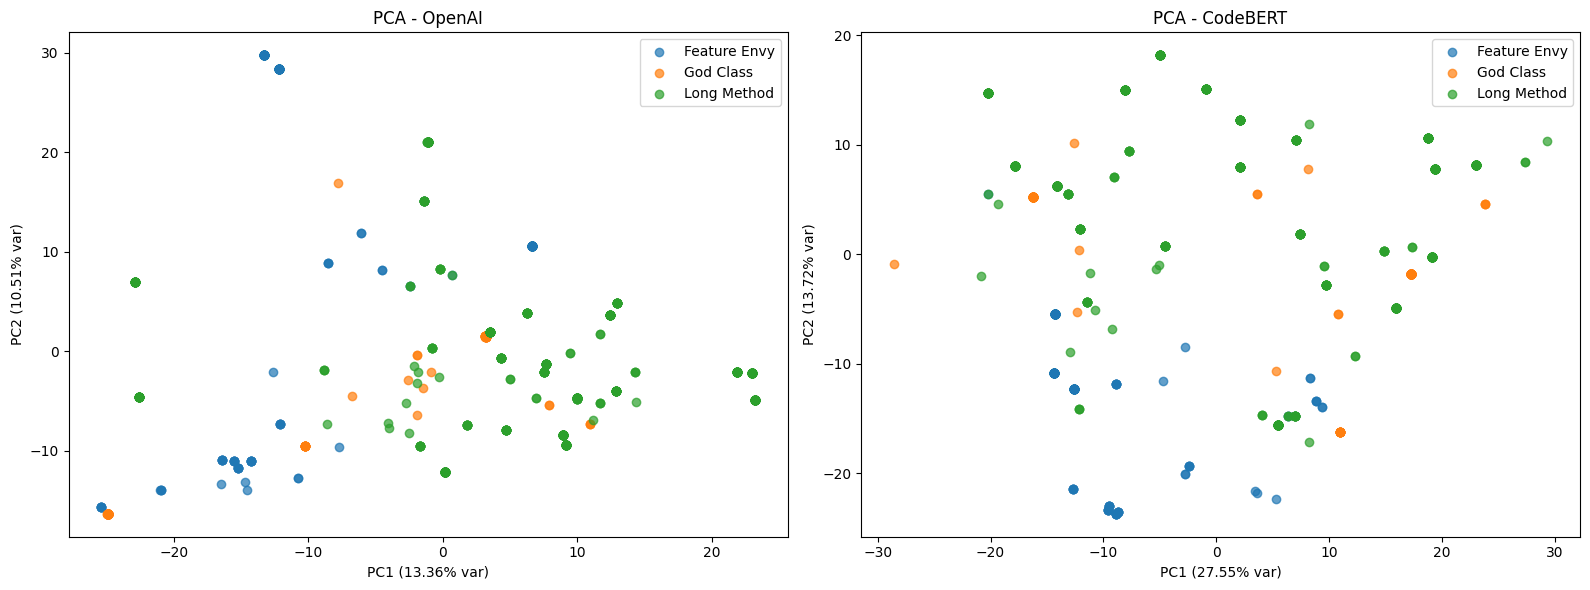

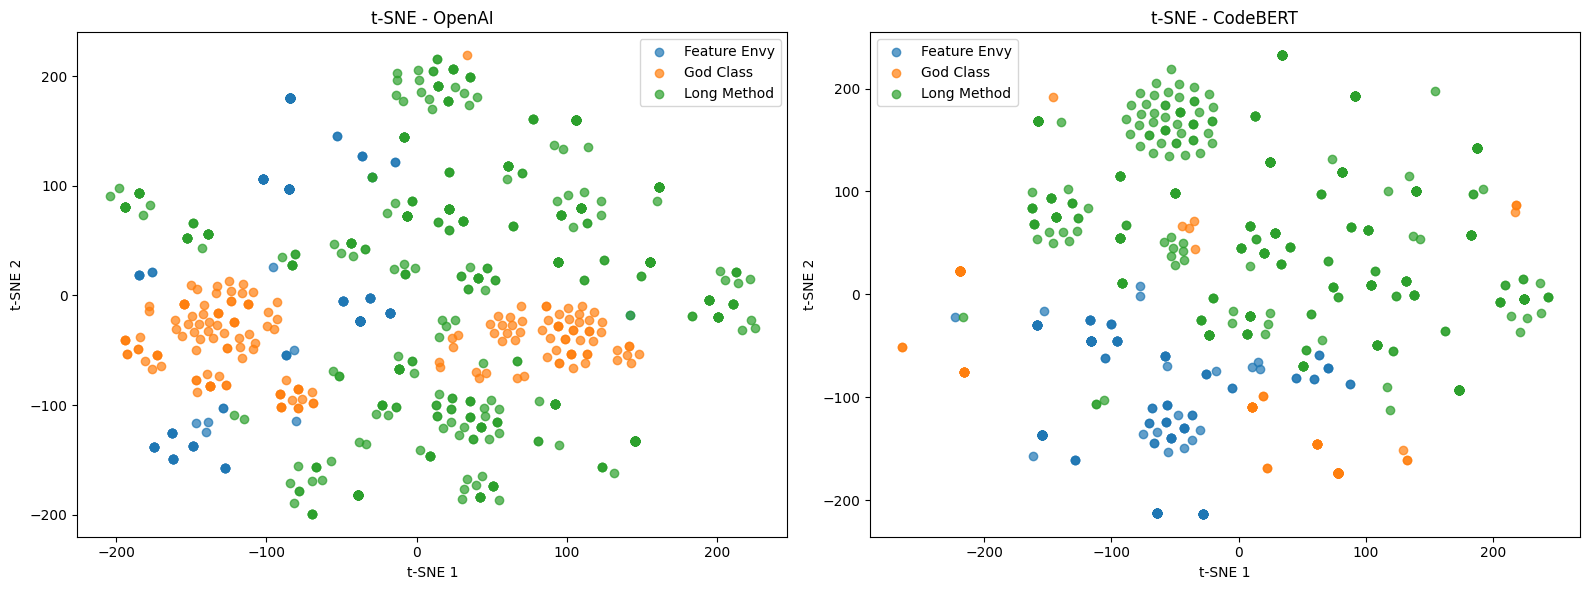

In [187]:
import pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

with open(path_openai, "rb") as f:
    df_openai = pickle.load(f)

with open(path_codebert, "rb") as f:
    df_codebert = pickle.load(f)

if isinstance(df_openai, dict):
    df_openai = pd.DataFrame(df_openai)

if isinstance(df_codebert, dict):
    df_codebert = pd.DataFrame(df_codebert)

print("Columnas OpenAI:", df_openai.columns.tolist())
print("Columnas CodeBERT:", df_codebert.columns.tolist())

label_col = "smell"
embedding_col_openai = "embedding"
embedding_col_codebert = "embedding"

def get_xy(df, emb_col, label_col):
    df = df[[emb_col, label_col]].dropna().copy()
    X = np.vstack(df[emb_col].apply(lambda x: np.array(x)).values)
    y = df[label_col].astype(str).values
    X = StandardScaler().fit_transform(X)
    return X, y

def plot_2d(ax, X2d, y, title, xlabel, ylabel):
    for cls in np.unique(y):
        idx = (y == cls)
        ax.scatter(X2d[idx, 0], X2d[idx, 1], alpha=0.7, label=cls)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

Xo, yo = get_xy(df_openai, embedding_col_openai, label_col)
Xc, yc = get_xy(df_codebert, embedding_col_codebert, label_col)

# PCA
pca_o = PCA(n_components=2, random_state=42)
pca_c = PCA(n_components=2, random_state=42)
Xo_pca = pca_o.fit_transform(Xo)
Xc_pca = pca_c.fit_transform(Xc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_2d(axes[0], Xo_pca, yo, "PCA - OpenAI",
        f"PC1 ({pca_o.explained_variance_ratio_[0]*100:.2f}% var)",
        f"PC2 ({pca_o.explained_variance_ratio_[1]*100:.2f}% var)")
plot_2d(axes[1], Xc_pca, yc, "PCA - CodeBERT",
        f"PC1 ({pca_c.explained_variance_ratio_[0]*100:.2f}% var)",
        f"PC2 ({pca_c.explained_variance_ratio_[1]*100:.2f}% var)")
plt.tight_layout()
plt.show()

# t-SNE
tsne_o = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
tsne_c = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)

Xo_tsne = tsne_o.fit_transform(Xo)
Xc_tsne = tsne_c.fit_transform(Xc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_2d(axes[0], Xo_tsne, yo, "t-SNE - OpenAI", "t-SNE 1", "t-SNE 2")
plot_2d(axes[1], Xc_tsne, yc, "t-SNE - CodeBERT", "t-SNE 1", "t-SNE 2")
plt.tight_layout()
plt.show()

## Varianza acumulada de PCA


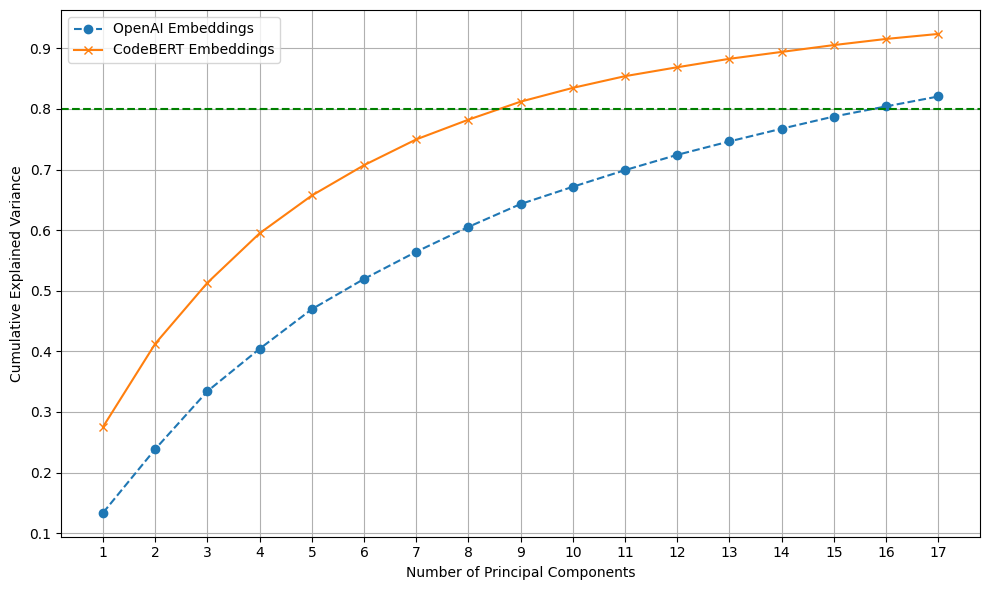

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

with open(path_openai, "rb") as f:
    df_openai = pickle.load(f)

with open(path_codebert, "rb") as f:
    df_codebert = pickle.load(f)

if isinstance(df_openai, dict):
    df_openai = pd.DataFrame(df_openai)

if isinstance(df_codebert, dict):
    df_codebert = pd.DataFrame(df_codebert)

label_col = "smell"
embedding_col = "embedding"

def get_xy_for_pca(df, emb_col, label_col):
    df = df[[emb_col, label_col]].dropna().copy()
    X = np.vstack(df[emb_col].apply(lambda x: np.array(x)).values)
    X = StandardScaler().fit_transform(X)
    return X

Xo = get_xy_for_pca(df_openai, embedding_col, label_col)
Xc = get_xy_for_pca(df_codebert, embedding_col, label_col)

n_components_to_test = 17

# PCA para OpenAI
pca_o_full = PCA(n_components=min(n_components_to_test, Xo.shape[1]), random_state=42)
pca_o_full.fit(Xo)
cum_variance_o = np.cumsum(pca_o_full.explained_variance_ratio_)

# PCA para CodeBERT
pca_c_full = PCA(n_components=min(n_components_to_test, Xc.shape[1]), random_state=42)
pca_c_full.fit(Xc)
cum_variance_c = np.cumsum(pca_c_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_variance_o) + 1), cum_variance_o, marker='o', linestyle='--', label='OpenAI Embeddings')
plt.plot(range(1, len(cum_variance_c) + 1), cum_variance_c, marker='x', linestyle='-', label='CodeBERT Embeddings')
plt.axhline(y=0.8, color='g', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.xticks(range(1, len(cum_variance_o) + 1))
plt.tight_layout()
plt.savefig('cumulative_variance_pca.png', dpi=300, bbox_inches='tight')
plt.show()